# 🔮 Gaussian Mixture Models (GMM) - Complete Learning Guide

## Overview
Gaussian Mixture Models provide a probabilistic approach to clustering using soft assignments. Each data point has a probability of belonging to each cluster, enabling more nuanced clustering than hard assignments. Uses Expectation-Maximization algorithm.

## Key Topics Covered:
1. **GMM Basics** - Probabilistic clustering fundamentals
2. **Soft vs Hard Assignments** - Probability of membership
3. **EM Algorithm** - Expectation-Maximization process
4. **Choosing Components** - BIC, AIC criteria
5. **Covariance Types** - Full, tied, diag, spherical
6. **Convergence** - EM algorithm convergence
7. **Density Estimation** - PDF from GMM
8. **Applications** - When to use GMM

---

## References:
- [Gaussian Mixture Models](https://en.wikipedia.org/wiki/Mixture_model#Gaussian_mixture_model)
- [scikit-learn GaussianMixture](https://scikit-learn.org/stable/modules/mixture.html)
- [EM Algorithm](https://www.youtube.com/watch?v=REypj2sy_5U)

## 📚 Section 1: Import Libraries

In [6]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🔮 Section 2: GMM Basics


🔮 EXAMPLE 1: Basic Gaussian Mixture Model

✅ GMM Results:
  Number of components: 3
  BIC score: 2150.3398
  AIC score: 2087.3755
  Log-likelihood: -3.4223
  Cluster sizes: [100 100 100]
  Converged: True
  Iterations: 2


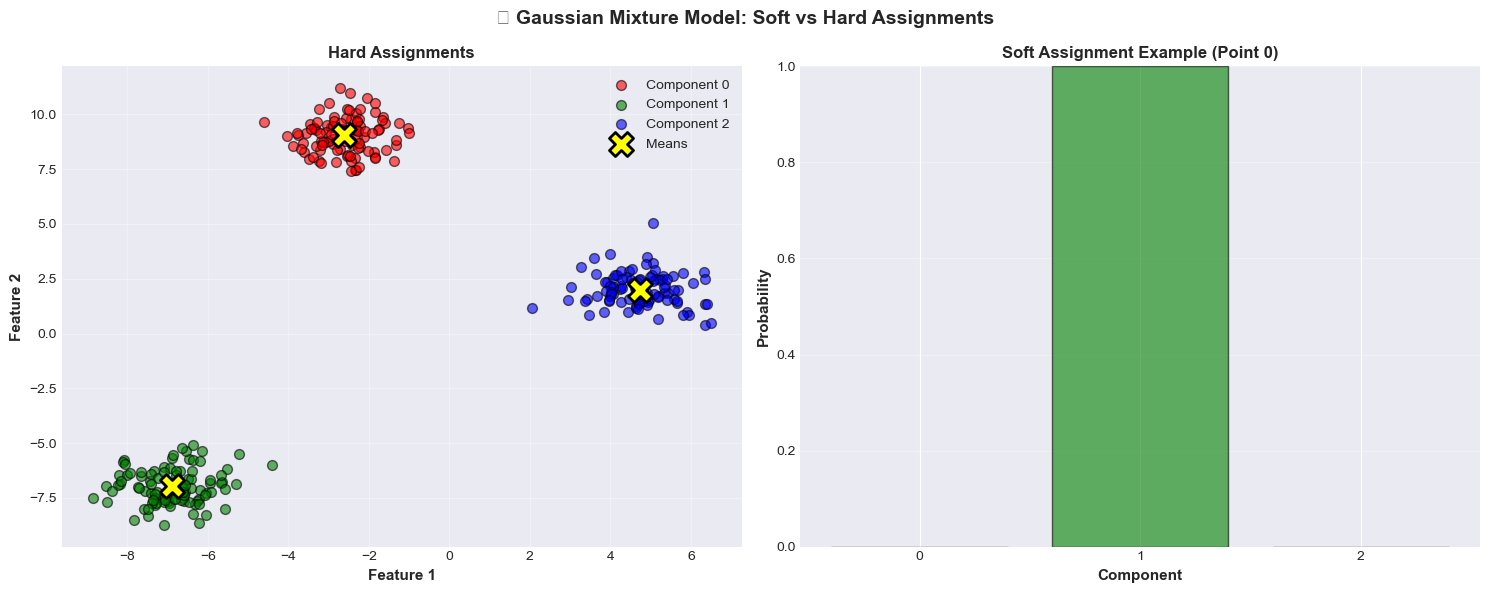

In [7]:
# Example 1: Basic GMM
print("\n" + "="*70)
print("🔮 EXAMPLE 1: Basic Gaussian Mixture Model")
print("="*70)

# Create synthetic data
X, y_true = make_blobs(n_samples=300, centers=3, n_features=2, 
                        cluster_std=0.8, random_state=42)

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
labels_hard = gmm.fit_predict(X)
probs = gmm.predict_proba(X)

print(f"\n✅ GMM Results:")
print(f"  Number of components: 3")
print(f"  BIC score: {gmm.bic(X):.4f}")
print(f"  AIC score: {gmm.aic(X):.4f}")
print(f"  Log-likelihood: {gmm.score(X):.4f}")
print(f"  Cluster sizes: {np.bincount(labels_hard)}")
print(f"  Converged: {gmm.converged_}")
print(f"  Iterations: {gmm.n_iter_}")

# Visualization - Hard assignments
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🔮 Gaussian Mixture Model: Soft vs Hard Assignments', fontsize=14, fontweight='bold')

# Hard assignments
ax = axes[0]
colors = ['red', 'green', 'blue']
for i in range(3):
    mask = labels_hard == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Component {i}',
              s=50, alpha=0.6, edgecolors='k')

ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='yellow', marker='X',
          s=300, edgecolors='black', linewidth=2, label='Means')

ax.set_xlabel('Feature 1', fontsize=11, fontweight='bold')
ax.set_ylabel('Feature 2', fontsize=11, fontweight='bold')
ax.set_title('Hard Assignments', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Soft assignments (uncertainty of one point)
ax = axes[1]
# Sample a few points and show their probabilities
sample_indices = [0, 50, 100, 150, 200, 250]
bars = ax.bar(range(3), probs[sample_indices[0]], color=colors, alpha=0.6, edgecolor='black')
ax.set_xlabel('Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Probability', fontsize=11, fontweight='bold')
ax.set_title('Soft Assignment Example (Point 0)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.set_xticks([0, 1, 2])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 📊 Section 3: Choosing Optimal Components


📊 EXAMPLE 2: Choosing Optimal Number of Components

🔍 Testing different numbers of components:
  n= 1: BIC=3753.03, AIC=3734.51
  n= 3: BIC=2150.34, AIC=2087.38
  n= 5: BIC=2203.31, AIC=2095.90
  n= 3: BIC=2150.34, AIC=2087.38
  n= 5: BIC=2203.31, AIC=2095.90
  n=10: BIC=2341.79, AIC=2123.27
  n=10: BIC=2341.79, AIC=2123.27


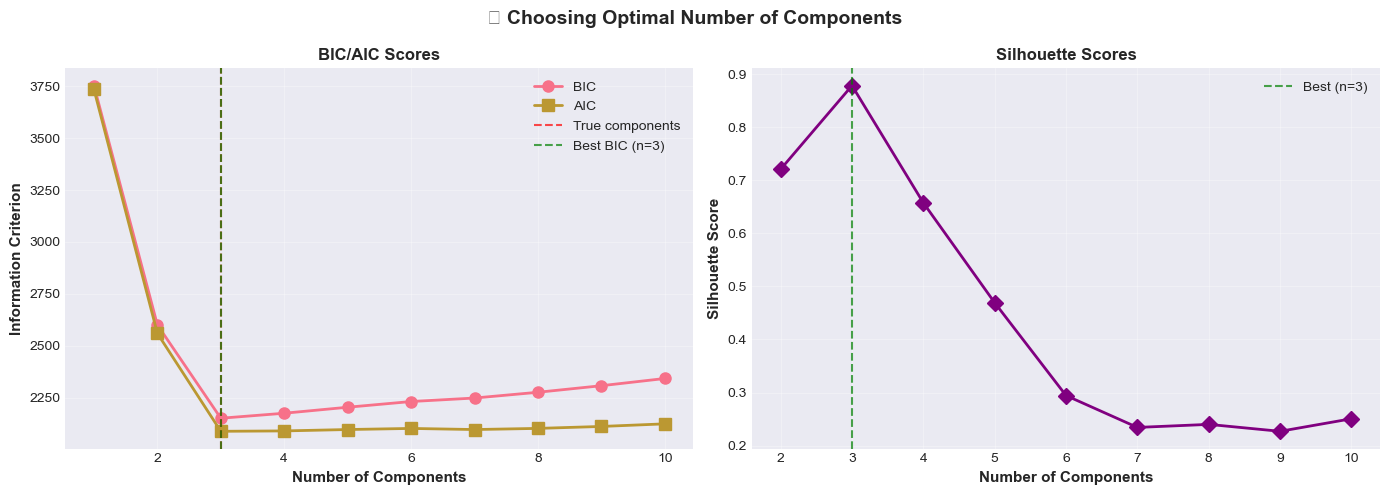


✅ Component Selection:
  BIC suggests: 3 components (lower BIC is better)
  Silhouette suggests: 3 components


In [8]:
# Example 2: BIC and AIC
print("\n" + "="*70)
print("📊 EXAMPLE 2: Choosing Optimal Number of Components")
print("="*70)

n_components_range = range(1, 11)
bic_scores = []
aic_scores = []
silhouette_scores = []

print(f"\n🔍 Testing different numbers of components:")
for n_comp in n_components_range:
    gmm_temp = GaussianMixture(n_components=n_comp, random_state=42)
    labels_temp = gmm_temp.fit_predict(X)
    
    bic_scores.append(gmm_temp.bic(X))
    aic_scores.append(gmm_temp.aic(X))
    
    if n_comp > 1:
        sil_score = silhouette_score(X, labels_temp)
        silhouette_scores.append(sil_score)
    else:
        silhouette_scores.append(0)
    
    if n_comp in [1, 3, 5, 10]:
        print(f"  n={n_comp:2d}: BIC={bic_scores[-1]:.2f}, AIC={aic_scores[-1]:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Choosing Optimal Number of Components', fontsize=14, fontweight='bold')

# BIC and AIC
ax = axes[0]
ax.plot(n_components_range, bic_scores, 'o-', linewidth=2, markersize=8, label='BIC')
ax.plot(n_components_range, aic_scores, 's-', linewidth=2, markersize=8, label='AIC')
ax.axvline(x=3, color='r', linestyle='--', alpha=0.7, label='True components')
best_n_bic = n_components_range[np.argmin(bic_scores)]
ax.axvline(x=best_n_bic, color='g', linestyle='--', alpha=0.7, label=f'Best BIC (n={best_n_bic})')
ax.set_xlabel('Number of Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Information Criterion', fontsize=11, fontweight='bold')
ax.set_title('BIC/AIC Scores', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Silhouette
ax = axes[1]
ax.plot(n_components_range[1:], silhouette_scores[1:], 'D-', linewidth=2, markersize=8, color='purple')
best_n_sil = n_components_range[np.argmax(silhouette_scores)]
ax.axvline(x=best_n_sil, color='g', linestyle='--', alpha=0.7, label=f'Best (n={best_n_sil})')
ax.set_xlabel('Number of Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
ax.set_title('Silhouette Scores', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Component Selection:")
print(f"  BIC suggests: {best_n_bic} components (lower BIC is better)")
print(f"  Silhouette suggests: {best_n_sil} components")

## 🎨 Section 4: Covariance Types

## 📈 Section 5: GMM on Real Dataset


📈 EXAMPLE 4: GMM on Iris Dataset

✅ GMM on Iris Dataset:
  BIC: 842.7177
  Log-likelihood: -2.5251
  Component sizes: [42 59 49]


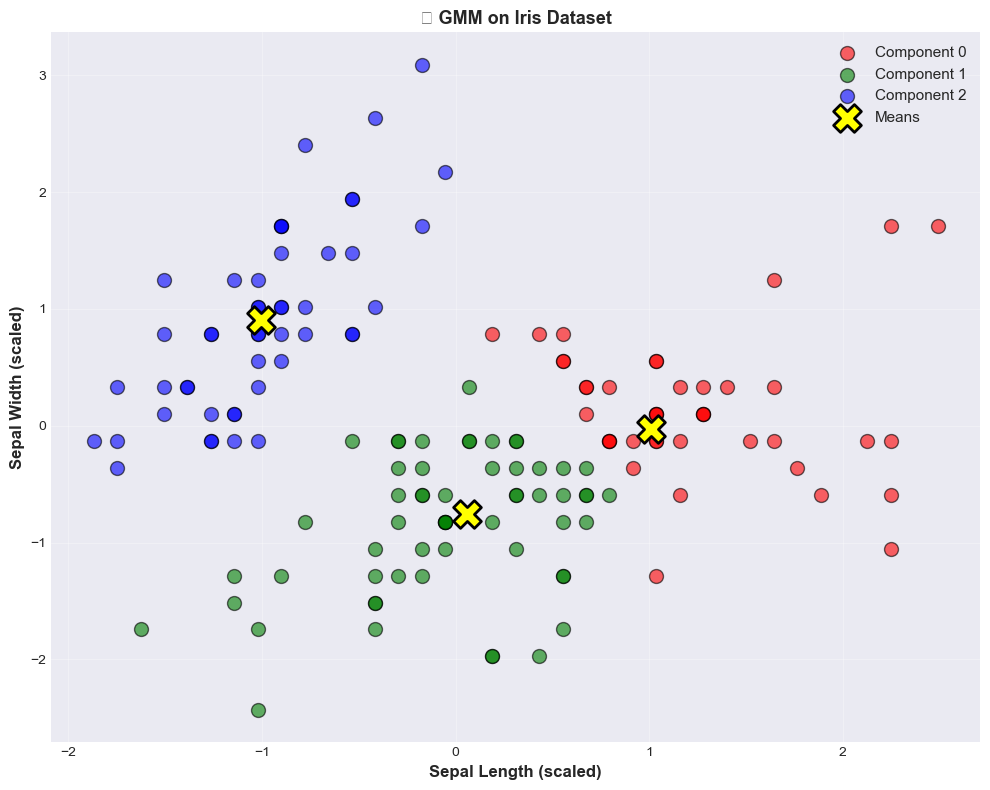

In [9]:
# Example 4: GMM on Iris
print("\n" + "="*70)
print("📈 EXAMPLE 4: GMM on Iris Dataset")
print("="*70)

iris = load_iris()
X_iris = iris.data[:, :2]

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

gmm_iris = GaussianMixture(n_components=3, random_state=42)
labels_iris = gmm_iris.fit_predict(X_iris_scaled)
probs_iris = gmm_iris.predict_proba(X_iris_scaled)

print(f"\n✅ GMM on Iris Dataset:")
print(f"  BIC: {gmm_iris.bic(X_iris_scaled):.4f}")
print(f"  Log-likelihood: {gmm_iris.score(X_iris_scaled):.4f}")
print(f"  Component sizes: {np.bincount(labels_iris)}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'green', 'blue']
for i in range(3):
    mask = labels_iris == i
    ax.scatter(X_iris_scaled[mask, 0], X_iris_scaled[mask, 1],
              c=colors[i], label=f'Component {i}', s=100, alpha=0.6, edgecolors='k')

ax.scatter(gmm_iris.means_[:, 0], gmm_iris.means_[:, 1], c='yellow', marker='X',
          s=400, edgecolors='black', linewidth=2, label='Means')

ax.set_xlabel('Sepal Length (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sepal Width (scaled)', fontsize=12, fontweight='bold')
ax.set_title('📈 GMM on Iris Dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 Section 6: GMM - Advantages & Disadvantages

### ✅ Advantages:
1. **Probabilistic model** - Soft assignments with uncertainty
2. **Interpretable** - Probability scores meaningful
3. **Flexible covariances** - Different covariance structures
4. **Model selection** - BIC/AIC for choosing components
5. **Generative model** - Can generate new samples
6. **Density estimation** - Estimate probability density

### ❌ Disadvantages:
1. **Assumes Gaussian** - May not fit non-Gaussian data
2. **Local optima** - EM can converge to local minimum
3. **Slow training** - EM iterative algorithm
4. **Initialization sensitive** - Initialization affects results
5. **Requires scaling** - Feature scaling important
6. **High-dimensional issues** - Struggles in high dimensions

### When to Use:
- When soft assignments needed
- Probabilistic approach desired
- Uncertainty quantification important
- Approximately Gaussian clusters
- Generating new samples
- Density estimation

In [10]:
# Example 5: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "GMM: Probabilistic clustering using soft assignments",
    "Each point has probability of belonging to each component",
    "EM Algorithm: Iterative Expectation-Maximization",
    "BIC/AIC: Information criteria for model selection",
    "BIC prefers simpler models (penalizes complexity more)",
    "Covariance types: Full (flexible) to Spherical (simple)",
    "Assumes Gaussian distributions - may not fit all data",
    "Always scale features before GMM!",
    "Soft assignments useful for: uncertainty quantification",
    "Can generate new samples from learned distribution",
    "EM sensitive to initialization - try multiple seeds",
    "Great for probabilistic models and density estimation!"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. GMM: Probabilistic clustering using soft assignments

 2. Each point has probability of belonging to each component

 3. EM Algorithm: Iterative Expectation-Maximization

 4. BIC/AIC: Information criteria for model selection

 5. BIC prefers simpler models (penalizes complexity more)

 6. Covariance types: Full (flexible) to Spherical (simple)

 7. Assumes Gaussian distributions - may not fit all data

 8. Always scale features before GMM!

 9. Soft assignments useful for: uncertainty quantification

10. Can generate new samples from learned distribution

11. EM sensitive to initialization - try multiple seeds

12. Great for probabilistic models and density estimation!

